In [39]:
import string
from random import random

import torch
from models import *

data = open('names.txt', 'r').read().splitlines(keepends=False)
print(data[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [2]:
bigram = Bigram()
bigram.fit(data)

In [3]:
bigram.make(5)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [4]:
bigram.loss(data)

2.4543561935424805

In [2]:
generator = torch.Generator().manual_seed(1234)
nn = NN(generator=generator)

nn.fit(data)

Loss=2.4627


In [3]:
generator = torch.Generator().manual_seed(1234)
nn.make(generator=generator)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [40]:
stoi = {s: i+1 for i, s in enumerate(string.ascii_lowercase)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [149]:
context_size = 3

def build_datasets(data):
    X, Y = [], []
    for word in data:
        context = [0] * context_size
        for char in word + '.':
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(1234)
random.shuffle(data)

n1 = int(len(data) * 0.8)
n2 = int(len(data) * 0.9)

Xtrain, ytrain = build_datasets(data[:n1])
Xdev, ydev = build_datasets(data[n1:n2])
Xtest, ytest = build_datasets(data[n2:])

In [280]:
generator = torch.Generator().manual_seed(1234)
batch_size = 32

embed_size = 10
W1_inputs = embed_size * context_size
L1_outputs = 200
L2_outputs = 150
num_epochs = 200_000

C = torch.randn((27, 10), generator=generator, requires_grad=True)
W1 = torch.randn((W1_inputs, L1_outputs), generator=generator, requires_grad=True)
b1 = torch.randn(L1_outputs, generator=generator, requires_grad=True)
W2 = torch.randn((L1_outputs, L2_outputs), generator=generator, requires_grad=True)
b2 = torch.randn(L2_outputs, generator=generator, requires_grad=True)
Wout = torch.randn((L2_outputs, 27), generator=generator, requires_grad=True)
bout = torch.randn(27, generator=generator, requires_grad=True)

params = [p for p in [C, W1, b1, W2, b2, Wout, bout]]

In [281]:
sum(p.nelement() for p in params)

40697

In [282]:
def learning_rate(epoch):
    return 0.1 if epoch < num_epochs * 3 / 4 else 0.001

In [283]:
stepi = []
lossi = []

In [284]:
alpha = 0.0001
for epoch in range(num_epochs):
    # encode data
    idx = torch.randint(len(Xtrain), size=(batch_size,))
    xenc = C[Xtrain[idx]]
    # go through layers
    h = torch.tanh(xenc.view(-1, W1_inputs) @ W1 + b1)
    h2 = torch.tanh(h @ W2 + b2)
    logits = h2 @ Wout + bout
    # softmax
    loss = F.cross_entropy(logits, ytrain[idx])
    reg = (W1**2).sum() + (b1**2).sum() + (W2**2).sum() + (b2**2).sum() + (Wout**2).sum() + (bout**2).sum() + (C**2).sum()
    loss += alpha * reg

    # backward pass
    for p in params:
        p.grad = None

    loss.backward()
    # update
    for p in params:
        p.data += -learning_rate(epoch) * p.grad

    stepi.append(epoch)
    lossi.append(loss.log10().item())

print(loss)

tensor(2.0134, grad_fn=<AddBackward0>)


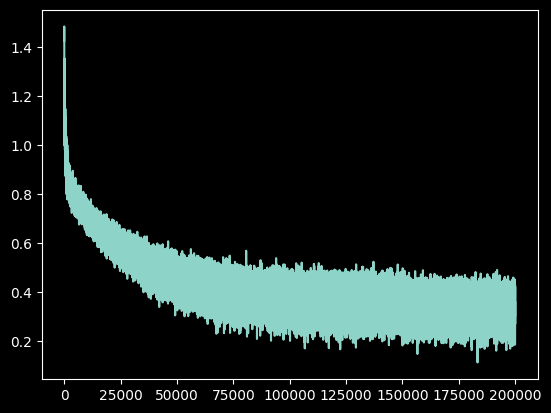

In [285]:
import matplotlib.pyplot as plt
plt.plot(stepi, lossi)

In [290]:
xenc = C[Xdev]
h = torch.tanh(xenc.view(-1, W1_inputs) @ W1 + b1)
h2 = torch.tanh(h @ W2 + b2)
logits = h2 @ Wout + bout
# softmax
loss = F.cross_entropy(logits, ydev)
loss.item()

2.103553295135498

In [291]:
generator = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    context = [0] * context_size
    out = []
    while True:
        xenc = C[torch.tensor(context)]
        h = torch.tanh(xenc.view(1, -1) @ W1 + b1)
        h2 = torch.tanh(h @ W2 + b2)
        logits = h2 @ Wout + bout

        probs = F.softmax(logits, dim=1)

        idx = torch.multinomial(probs, num_samples=1, generator=generator).item()
        out.append(itos[idx])

        context = context[1:] + [idx]
        if idx == 0:
            break

    print(''.join(out))

cex.
mariah.
makima.
kayden.
maimitta.
noluwan.
katar.
samiyah.
javer.
gotti.
moriellah.
jazireda.
kaley.
maside.
enkaviyah.
fobs.
millie.
brtahlan.
kashra.
antil.
